#**Business Questions and Hypotheses:**


**1.Does price influence quantity sold? (Main Hypothesis Test)**

H_0 (Null):There is no statistically significant relationship between product price and quantity sold.

H_1 (Alternative):There is a statistically significant negative relationship between product price and quantity sold.

**2.Do repeat customers spend more?**

**Approach (Exploratory Data Analysis):** Customer purchasing behavior will be analyzed by segmenting customers into repeat and one-time buyers based on transaction frequency. Total spending will be compared across these groups to identify differences in purchasing patterns.

**3.How do sales trends evolve over time?**

**Approach (Time Series Analysis):** Revenue will be aggregated over time (e.g., monthly) to analyze trends, patterns, and potential seasonality in sales performance.

**4.Crypto Dataset (API): How does cryptocurrency volatility differ across assets?**

**Approach (Exploratory Data Analysis):** Price movements across different cryptocurrencies will be examined to assess and compare volatility levels, providing insight into relative risk and stability among assets.

# **Load First Dataset**

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import plotly.express as px

In [ ]:
df = pd.read_csv("/content/clean_ecommerce_data.csv")
#df.head()

## **Correlation and Regression**

**1.Does price influence quantity sold? (Main Hypothesis Test)**

H_1 (Null):There is no statistically significant relationship between product price and quantity sold.

H_1 (Alternative):There is a statistically significant negative relationship between product price and quantity sold.

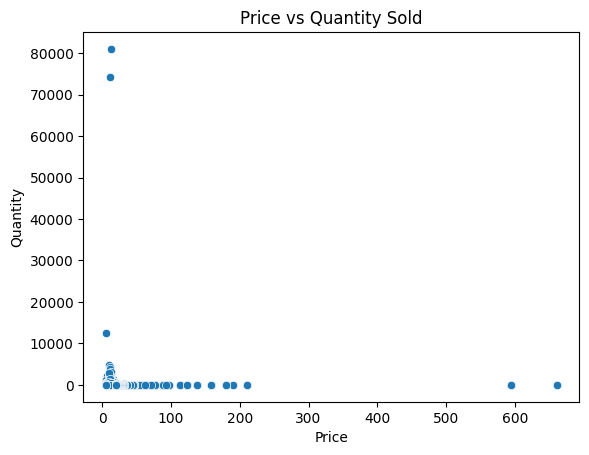

In [ ]:
#Visual inspection
sns.scatterplot(data=df, x='Price', y='Quantity')
plt.title('Price vs Quantity Sold')
plt.show()



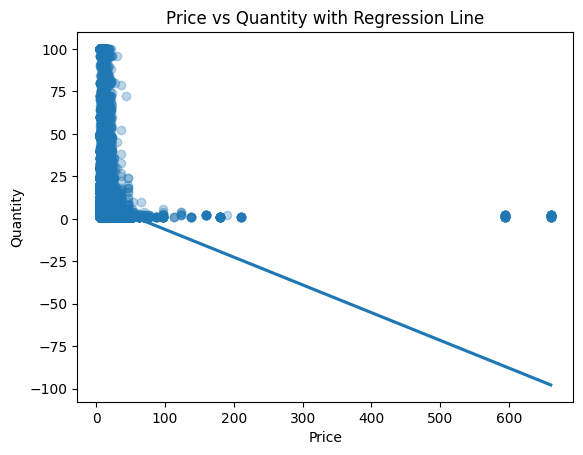

In [ ]:
sns.regplot(data=df_filtered, x='Price', y='Quantity',
            scatter_kws={'alpha':0.3}, ci=None)
plt.title('Price vs Quantity with Regression Line')
plt.show()

In [ ]:
# Correlation test
from scipy.stats import pearsonr
corr, p_value = pearsonr(df['Price'], df['Quantity'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.011685344275551237
P-value: 3.074595780075391e-17


In [ ]:
# Regression anaysis
X = sm.add_constant(df['Price'])
y = df['Quantity']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     71.30
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.07e-17
Time:                        13:08:14   Log-Likelihood:            -3.3827e+06
No. Observations:              522101   AIC:                         6.765e+06
Df Residuals:                  522099   BIC:                         6.765e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5920      0.409     33.240      0.0

- Although the p-value indicates statistical significance (p < 0.05), the correlation coefficient is extremely close to zero

- This suggests that price alone does not significantly influence purchasing quantity in this dataset.

### Without extreme values

In [ ]:
# filter top 1% of Quantity
q_high = df['Quantity'].quantile(0.99)

df_filtered = df[df['Quantity'] <= q_high]

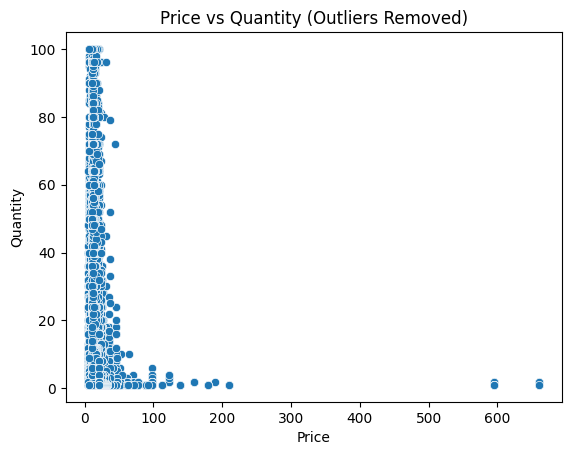

In [ ]:
sns.scatterplot(data=df_filtered, x='Price', y='Quantity')
plt.title('Price vs Quantity (Outliers Removed)')
plt.show()

In [ ]:
corr, p_value = pearsonr(df_filtered['Price'], df_filtered['Quantity'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.10348595107936591
P-value: 0.0


- After removing extreme outliers, a statistically significant negative relationship between price and quantity sold was observed.

- However, the strength of this relationship remains weak, indicating that while price has some influence on purchasing behavior, it is not a strong predictor of quantity sold.

- Therefore, although the null hypothesis is rejected, price alone does not meaningfully explain variations in purchasing behavior.

## **1st EDA**

**2.Do repeat customers spend more?**

Approach (Exploratory Data Analysis): Customer purchasing behavior will be analyzed by segmenting customers into repeat and one-time buyers based on transaction frequency. Total spending will be compared across these groups to identify differences in purchasing patterns.

In [ ]:
# creating customer summary from transactions
customer_summary = df.groupby('CustomerNo').agg({'TransactionNo': 'nunique','Revenue': 'sum'}).rename(columns={'TransactionNo': 'NumTransactions','Revenue': 'TotalSpend'})

In [ ]:
# classification of customers
customer_summary['CustomerType'] = np.where(customer_summary['NumTransactions'] > 1,'Repeat','One-time')

In [ ]:
# comparing spending
customer_summary.groupby('CustomerType')['TotalSpend'].mean()

,TotalSpend
CustomerType,
One-time,3660.639200
Repeat,18174.465337


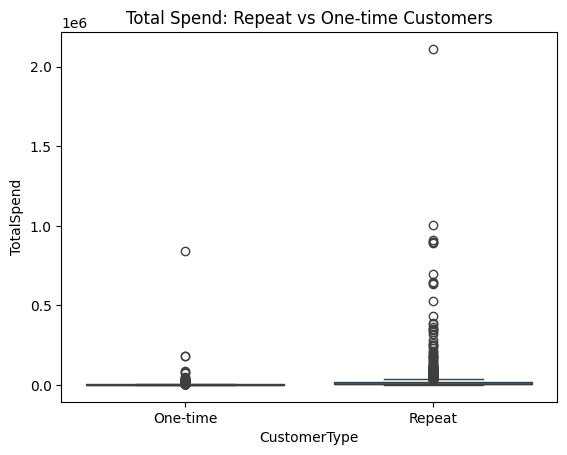

In [ ]:
# visual representation
sns.boxplot(data=customer_summary, x='CustomerType', y='TotalSpend')
plt.title('Total Spend: Repeat vs One-time Customers')
plt.show()

/tmp/ipykernel_18072/1841853343.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


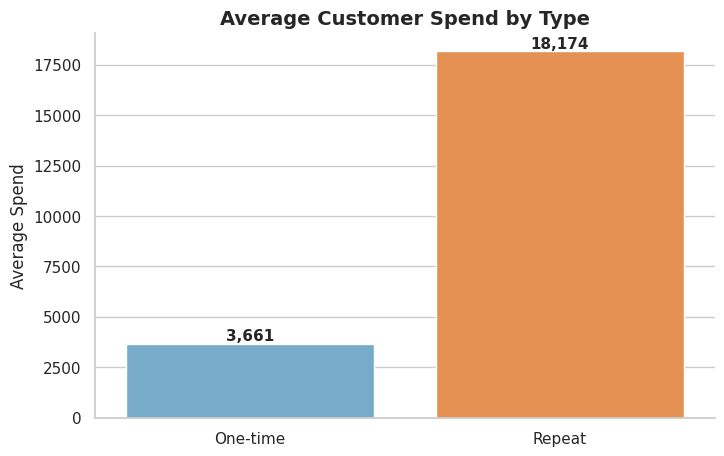

In [ ]:
# Prepare data
avg_spend = customer_summary.groupby('CustomerType')['TotalSpend'].mean().reset_index()

# Style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=avg_spend,
    x='CustomerType',
    y='TotalSpend',
    palette=['#6BAED6', '#FD8D3C']  # soft blue & orange
)

# Titles & labels
plt.title('Average Customer Spend by Type', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('Average Spend')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, weight='bold')

# Remove top/right borders
sns.despine()

plt.show()

- Repeat customers spend significantly more than one-time customers

- The distribution of spending among repeat customers also shows greater variability, with a higher concentration of high-value customers.

- This indicates that repeat customers contribute disproportionately to overall revenue, highlighting the importance of customer retention strategies.

## **Time series**

**3.How do sales trends evolve over time?**

Approach (Time Series Analysis): Revenue will be aggregated over time (e.g., monthly) to analyze trends, patterns, and potential seasonality in sales performance.

In [ ]:
# Revenue by month
monthly_sales = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()

In [ ]:
#monthly_sales

In [ ]:
# Creating time variable
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str))

#monthly_sales

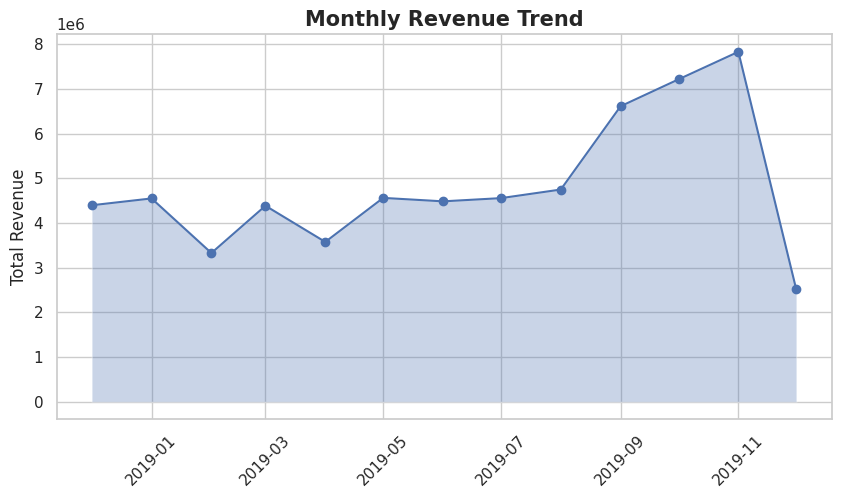

In [ ]:
plt.figure(figsize=(10,5))

plt.fill_between(monthly_sales['Date'], monthly_sales['Revenue'], alpha=0.3)
plt.plot(monthly_sales['Date'], monthly_sales['Revenue'], marker='o')

plt.title('Monthly Revenue Trend', fontsize=15, weight='bold')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

Monthly revenue shows a generally stable pattern in the first half of the year, followed by a strong upward trend from late summer into autumn, peaking in November.

This pattern suggests increased purchasing activity toward the end of the year, potentially driven by seasonal demand.

In [ ]:
#monthly diff
monthly_sales = monthly_sales.sort_values('Date')

monthly_sales['Revenue_diff'] = monthly_sales['Revenue'].diff()

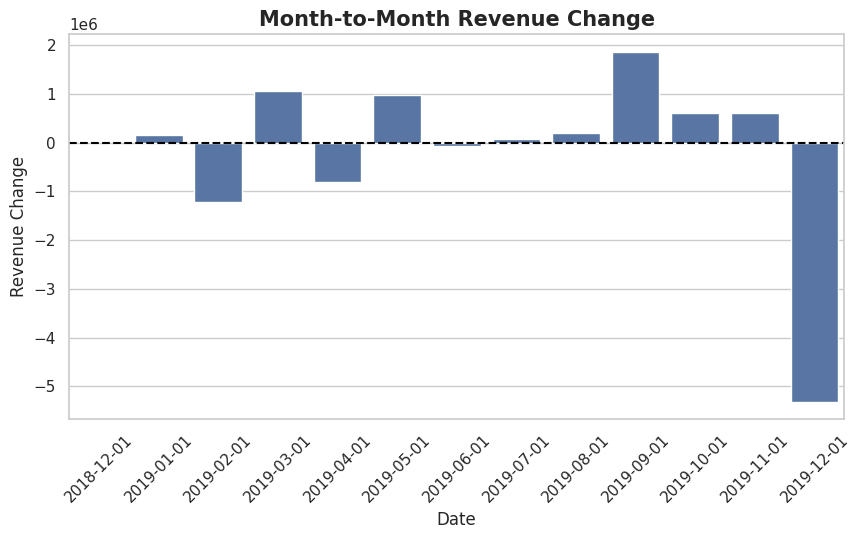

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(data=monthly_sales, x='Date', y='Revenue_diff')

plt.axhline(0, color='black', linestyle='--')

plt.title('Month-to-Month Revenue Change', fontsize=15, weight='bold')
plt.ylabel('Revenue Change')
plt.xticks(rotation=45)

plt.show()

Month-to-month revenue changes reveal significant fluctuations in sales performance, with periods of both growth and decline. Notably, several months exhibit strong positive growth, while others show declines, indicating variability in purchasing behavior.

## **Revenue by Country**

In [ ]:
df_map = df[~df['Country'].isin(['Unspecified', 'European Community'])]

In [ ]:
country_revenue = df_map.groupby('Country')['Revenue'].sum().reset_index()

In [ ]:
country_revenue['Revenue_log'] = np.log1p(country_revenue['Revenue'])

In [ ]:
id="tiered-map"
country_revenue['Tier'] = pd.qcut(country_revenue['Revenue'],q=4,
    labels=['Low', 'Medium', 'High', 'Top'])

In [ ]:
import plotly.express as px

fig = px.choropleth(
    country_revenue,
    locations='Country',
    locationmode='country names',
    color='Tier',
    color_discrete_map={
        'Low': '#D6EAF8',
        'Medium': '#5DADE2',
        'High': '#F5B041',
        'Top': '#E74C3C'
    },
    title='Global Revenue Distribution (Tiered)'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    title_font_size=20,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

# **Loading Second Dataset**

In [ ]:
df1 = pd.read_csv("https://raw.githubusercontent.com/Dee-M123/Project-E-commerce-Business-Transaction-and-Crypto-Analysis/refs/heads/main/Data/Cleaned/crypto_data_API.csv")
df1.head()

,price,date,coin
0,2972.575824,2025-12-21 06:02:03.631,ethereum
1,88096.923325,2025-12-21 06:02:08.076,bitcoin
2,77.100675,2025-12-21 06:04:12.047,litecoin
3,1.922524,2025-12-21 06:04:31.951,ripple
4,88067.806506,2025-12-21 07:01:28.981,bitcoin


**4.Crypto Dataset (API): How does cryptocurrency volatility differ across assets**?

Approach (Exploratory Data Analysis): Price movements across different cryptocurrencies will be examined to assess and compare volatility levels, providing insight into relative risk and stability among assets.

## 2nd EDA

In [ ]:
df1 = df1.sort_values(['coin', 'date'])

df1['returns'] = df1.groupby('coin')['price'].pct_change()

In [ ]:
#volatility per coin
volatility = df1.groupby('coin')['returns'].std().reset_index()
volatility = volatility.sort_values(by='returns', ascending=False)
volatility

,coin,returns
3,ripple,0.007357
1,ethereum,0.007023
2,litecoin,0.006437
0,bitcoin,0.005345


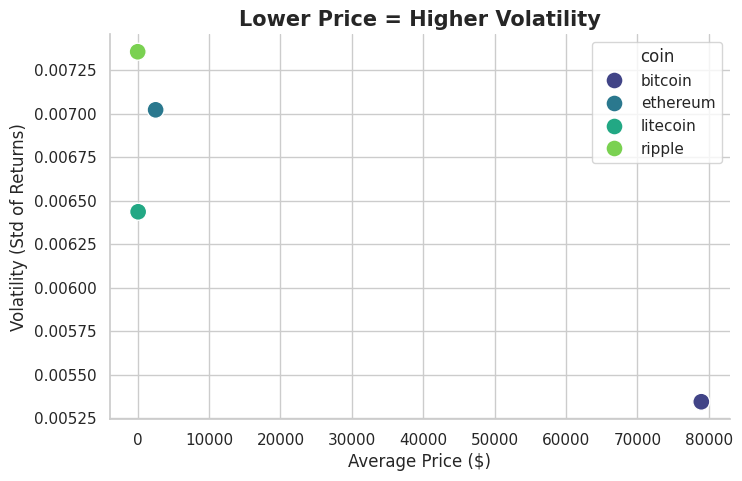

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x='price',
    y='volatility',
    hue='coin',
    palette='viridis',
    s=150
)

plt.title('Lower Price = Higher Volatility', fontsize=15, weight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('Volatility (Std of Returns)')

sns.despine()
plt.show()

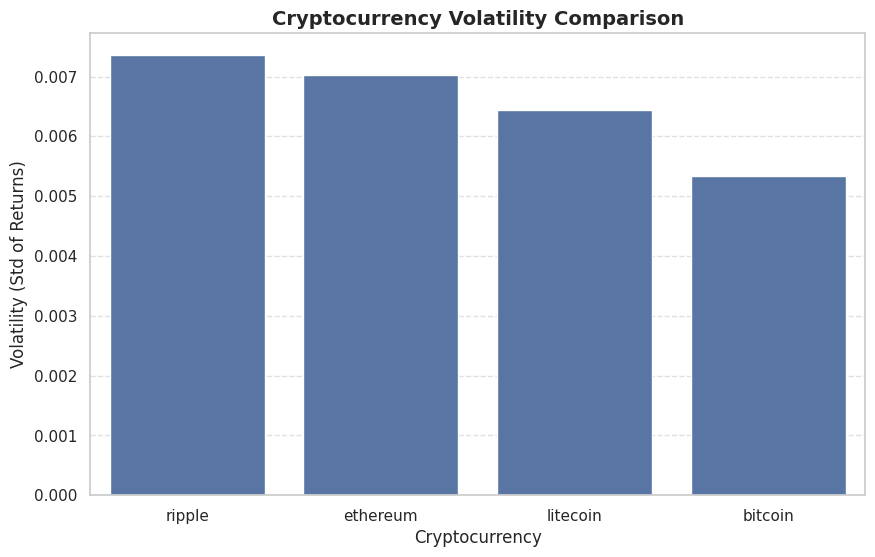

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=volatility, x='coin', y='returns')

plt.title('Cryptocurrency Volatility Comparison', fontsize=14, weight='bold')
plt.xlabel('Cryptocurrency')
plt.ylabel('Volatility (Std of Returns)')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

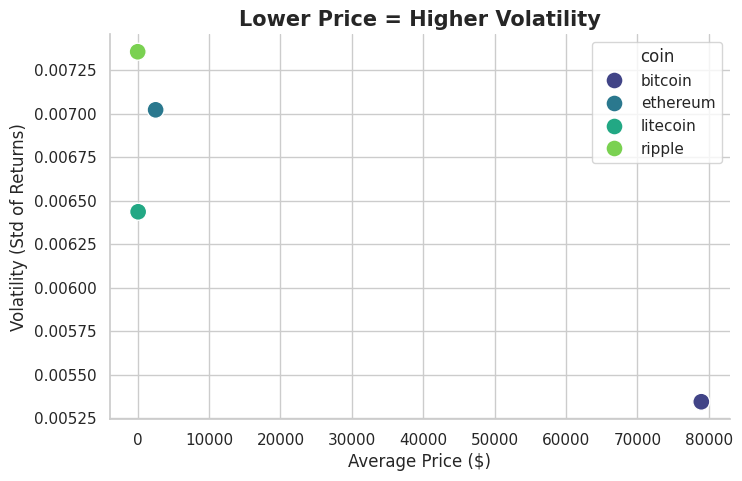

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x='price',
    y='volatility',
    hue='coin',
    palette='viridis',
    s=150
)

plt.title('Lower Price = Higher Volatility', fontsize=15, weight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('Volatility (Std of Returns)')

sns.despine()
plt.show()

- Cryptocurrency volatility varies across assets, with Ripple exhibiting the highest volatility and Bitcoin the lowest.

- This suggests that smaller or lower-priced cryptocurrencies tend to experience greater price fluctuations, while more established assets such as Bitcoin show relatively more stable behavior.

- These differences highlight varying levels of risk across cryptocurrencies.